# HW2

## 1. Fama-French三因子模型

Fama-French三因子模型的公式如下：
$$
R_i - R_F = \alpha_i + \beta_i(R_M - R_F) + s_i \cdot SMB + h_i \cdot HML + \epsilon_i
$$
其中：
- $R_i$：资产$i$的收益率
- $R_F$：无风险收益率
- $\alpha_i$：资产$i$的特有alpha值
- $\beta_i$：资产$i$对市场组合因子的敏感度
- $s_i$：资产$i$对公司规模因子的敏感度
- $h_i$：资产$i$对账面市值比因子的敏感度
- $\epsilon_i$：误差项，表示其他未被模型解释的因素对资产$i$收益率的影响

#### 模型的经济意义与应用场景
Fama-French三因子模型在金融领域具有重要的经济意义和广泛的应用场景。从理论上讲，它深化了对资产定价机制的理解，揭示了市场风险、公司规模和账面市值比这三个关键因素对股票收益的共同影响，为现代金融理论的发展提供了重要支持。在实际应用中，该模型为投资者提供了更全面的风险评估和投资决策工具。投资者可以通过分析资产对三个因子的敏感度，构建更优化的投资组合，以实现更高的风险调整后收益。此外，模型在资产配置、业绩评估和风险管理等方面也具有重要的指导作用，帮助投资者更好地应对复杂多变的金融市场环境。

#### 模型的局限性

尽管Fama-French三因子模型在解释股票收益方面取得了显著成就，但它并非完美无缺。模型的局限性主要体现在以下几个方面：首先，它无法解释某些特定类型的资产收益，例如某些受行业特定因素影响较大的股票。其次，在不同的市场环境和经济周期中，模型的解释能力可能会有所波动，这可能是因为市场结构、投资者行为等因素的变化导致的。最后，模型的因子构建相对较为复杂，需要大量的数据和计算资源，这在一定程度上限制了其在实际应用中的便捷性。因此，在使用Fama-French三因子模型时，投资者和研究人员需要充分认识到其局限性，并结合其他模型和分析方法，以更全面、准确地评估资产收益和风险。

## 2. 计算一年滚动alpha

导入包

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib

import rqdatac
rqdatac.init()

# 画图风格：尽量简洁清晰，便于观察滚动 alpha 的时序变化
plt.style.use('seaborn-v0_8-whitegrid')
# 设置 matplotlib 中文显示以及负号正常显示
# 优先使用系统常见中文字体（Windows 常见：Microsoft YaHei / SimHei），
# 若这些字体不存在，matplotlib 会回退至默认字体。
matplotlib.rcParams['font.sans-serif'] = ['Microsoft YaHei', 'SimHei']
matplotlib.rcParams['font.family'] = 'sans-serif'
# 解决负号 '-' 显示为方块的问题
matplotlib.rcParams['axes.unicode_minus'] = False

参数设置

In [3]:
# 样本区间：2010 年初到 2020 年底
start_date = '2010-01-01'
end_date = '2020-12-31'

# 一年滚动窗口：按题目要求使用 242 个交易日
window = 242

选出样本存续期内编号最小的10支股票

In [4]:
# 读取全部A股股票信息
# 先拿到全市场股票，再筛出沪市标的
all_stocks = rqdatac.all_instruments(type='CS')

# 不同环境下字段名可能略有差异，这里先统一关键字段
code_col = 'order_book_id'
name_col = 'symbol'
exchange_col = 'exchange'
listed_col = 'listed_date'
delisted_col = 'de_listed_date'

# 样本期边界，后面用于筛选“样本期内持续上市”的股票
eval_start = pd.Timestamp(start_date)
eval_end = pd.Timestamp(end_date)

# 将日期列转换为时间戳，方便做区间筛选
all_stocks = all_stocks.copy()
all_stocks[listed_col] = pd.to_datetime(all_stocks[listed_col], errors='coerce')
all_stocks[delisted_col] = pd.to_datetime(all_stocks[delisted_col], errors='coerce')

def normalize_stock_code(order_book_id: str) -> str:
    """把米筐的 order_book_id 转成 6 位股票代码。"""
    return str(order_book_id).split('.')[0]

# 筛选沪市股票，并进一步要求它们在整个样本期内持续上市
sh_stocks = all_stocks[all_stocks[exchange_col] == 'XSHG'].copy()
sh_stocks['code'] = sh_stocks[code_col].map(normalize_stock_code)
sh_stocks = sh_stocks[sh_stocks['code'].str.fullmatch(r'\d{6}')]
sh_stocks = sh_stocks[sh_stocks[listed_col].le(eval_start)]
sh_stocks = sh_stocks[sh_stocks[delisted_col].isna() | sh_stocks[delisted_col].ge(eval_end)]
sh_small_10 = sh_stocks.sort_values('code').head(10).reset_index(drop=True)

stock_codes = sh_small_10['code'].tolist()
stock_names = sh_small_10[name_col].tolist()
stock_order_book_ids = sh_small_10[code_col].tolist()

# 打印最终入样本的股票列表
universe = pd.DataFrame({'code': stock_codes, 'name': stock_names, 'order_book_id': stock_order_book_ids})
print('样本期内持续上市的沪市代码最小的 10 只股票：')
display(universe)

样本期内持续上市的沪市代码最小的 10 只股票：


C:\Users\Lenovo\AppData\Local\Temp\ipykernel_57956\2438736462.py:19: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  all_stocks[delisted_col] = pd.to_datetime(all_stocks[delisted_col], errors='coerce')


,code,name,order_book_id
0,600000,浦发银行,600000.XSHG
1,600004,白云机场,600004.XSHG
2,600006,东风股份,600006.XSHG
3,600007,中国国贸,600007.XSHG
4,600008,首创环保,600008.XSHG
5,600009,上海机场,600009.XSHG
6,600010,包钢股份,600010.XSHG
7,600011,华能国际,600011.XSHG
8,600012,皖通高速,600012.XSHG
9,600015,华夏银行,600015.XSHG


获取价格数据

In [5]:
# 一次性拉取 10 只股票的日线收盘价。
# 米筐 get_price 对多个 order_book_id 返回的是 MultiIndex 形式的数据：
# index = (order_book_id, date), column = close。
stock_raw = rqdatac.get_price(
    stock_order_book_ids,
    start_date=start_date,
    end_date=end_date,
    frequency='1d',
    fields='close',
    adjust_type='pre',
    expect_df=True
)

# 将 MultiIndex 数据还原成“日期为行、股票代码为列”的宽表
stock_close = stock_raw['close'].unstack('order_book_id').sort_index()
stock_close = stock_close.reindex(columns=stock_order_book_ids)
stock_close.columns = stock_codes

# 抓取沪深300指数收盘价
# 米筐指数代码通常使用 000300.XSHG，这里也保持列表输入，返回结构与股票一致
hs300_order_book_id = '000300.XSHG'
hs300_raw = rqdatac.get_price(
    [hs300_order_book_id],
    start_date=start_date,
    end_date=end_date,
    frequency='1d',
    fields='close',
    expect_df=True
)
hs300_close = hs300_raw['close'].unstack('order_book_id').sort_index().iloc[:, 0]
hs300_close.name = 'HS300'

# 将所有价格对齐到相同交易日，避免后面滚动计算时出现对齐问题
price_panel = pd.concat([stock_close, hs300_close], axis=1, join='inner').sort_index()
print(f'对齐后的价格表形状：{price_panel.shape}')
display(price_panel.head())

对齐后的价格表形状：(2674, 11)


,600000,600004,600006,600007,600008,600009,600010,600011,600012,600015,HS300
date,,,,,,,,,,,
2010-01-04,4.925122,4.955814,5.988922,8.088110,2.218920,14.680856,1.587577,4.956114,3.077459,3.487942,3535.229
2010-01-05,4.962310,4.975345,5.954254,7.828963,2.212713,14.779276,1.580644,5.005613,3.093187,3.575993,3564.038
2010-01-06,4.864691,4.902106,5.971588,7.903980,2.234437,14.516824,1.584110,4.974676,3.082702,3.445337,3541.727
2010-01-07,4.755450,4.775159,5.685576,8.006274,2.187886,14.369196,1.545981,4.863302,3.019790,3.374328,3471.456
2010-01-08,4.808908,4.970462,5.737578,7.931258,2.203403,14.713663,1.552913,4.863302,3.046003,3.397051,3480.130


计算日收益率并用向量化方法求 242 日滚动 alpha. 对每个滚动窗口，我们直接利用回归的闭式解：

$$\beta = \frac{\operatorname{Cov}(x,y)}{\operatorname{Var}(x)}, \quad \alpha = \mathbb{E}[y] - \beta\mathbb{E}[x]$$

其中所有期望、协方差、方差都用滚动窗口内的样本矩来计算。这样就不需要对每个交易日逐点做回归循环。

In [6]:
# 先统一计算日收益率，采用简单收益率 pct_change()
returns = price_panel.pct_change().dropna()
stock_ret = returns[stock_codes]
market_ret = returns['HS300']

# 242 日滚动窗口的样本矩
# mean_x: 沪深300收益率均值
# mean_y: 个股收益率均值（按列同时计算）
# mean_xy: 个股收益率与指数收益率乘积的均值
# mean_x2: 沪深300收益率平方的均值
mean_x = market_ret.rolling(window=window, min_periods=window).mean()
mean_y = stock_ret.rolling(window=window, min_periods=window).mean()
mean_xy = stock_ret.mul(market_ret, axis=0).rolling(window=window, min_periods=window).mean()
mean_x2 = market_ret.pow(2).rolling(window=window, min_periods=window).mean()

# 闭式解：beta = Cov(x,y) / Var(x)
# 这里用矩方法把协方差和方差展开成滚动均值，避免逐窗口调用回归模型
cov_xy = mean_xy - mean_y.mul(mean_x, axis=0)
var_x = mean_x2 - mean_x.pow(2)
beta = cov_xy.div(var_x, axis=0)

# alpha = E[y] - beta * E[x]
alpha = mean_y - beta.mul(mean_x, axis=0)

# 一般只在样本窗口完整时才有结果，因此前 241 个交易日会是 NaN
alpha = alpha.dropna(how='all')

print('滚动 alpha 已计算完成。')
print(f'可用样本期数：{len(alpha)}')

# 汇总统计：均值和标准差
# 生成用于展示的列名
display_names = {code: f'{code} {name}' for code, name in zip(stock_codes, stock_names)}
alpha = alpha.rename(columns=display_names)

summary = pd.DataFrame({
    'mean_alpha_per_day': alpha.mean(),
    'std_alpha_per_day': alpha.std(),
})
summary.index.name = 'stock'

print('滚动 alpha 汇总表：')
display(summary)

滚动 alpha 已计算完成。
可用样本期数：2432
滚动 alpha 汇总表：


,mean_alpha_per_day,std_alpha_per_day
stock,,
600000 浦发银行,0.000145,0.000711
600004 白云机场,0.000396,0.000798
600006 东风股份,0.000108,0.001269
600007 中国国贸,0.000208,0.000953
600008 首创环保,0.000123,0.001042
600009 上海机场,0.000707,0.000838
600010 包钢股份,0.000081,0.001404
600011 华能国际,0.000002,0.000879
600012 皖通高速,0.000184,0.001575


## 3. 构造因子

### 3.1 因子一：杜邦拆解ROE因子

目标：
- 获取财务数据并构建杜邦拆解特征；
- 通过时间序列滚动验证（walk-forward）训练最优参数。

说明：
- 特征采用：`资产周转率(TTM)`、`净利率(TTM)`、`权益乘数(TTM)`。
- 预测目标为下月个股相对沪深300的超额收益（截面预测）。

参数设置

In [7]:
train_start = '2010-01-01'
train_end = '2019-12-30'
label_end = '2020-01-31'  # 为了构造 2019-12 的下月收益标签
benchmark_id = '000300.XSHG'

全市场股票池（沪深）

In [8]:
instruments = rqdatac.all_instruments(type='CS').copy()
instruments['listed_date'] = pd.to_datetime(instruments['listed_date'], errors='coerce')
instruments['de_listed_date'] = pd.to_datetime(instruments['de_listed_date'], errors='coerce')
all_ids = instruments['order_book_id'].dropna().astype(str).tolist()

print(f'全市场股票数量（原始）：{len(all_ids)}')

全市场股票数量（原始）：5540


C:\Users\Lenovo\AppData\Local\Temp\ipykernel_57956\3760412022.py:3: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  instruments['de_listed_date'] = pd.to_datetime(instruments['de_listed_date'], errors='coerce')


交易日与月末交易日

In [9]:
all_trading_days = pd.DatetimeIndex(
    rqdatac.get_trading_dates(start_date=train_start, end_date=label_end)
)
month_ends = all_trading_days.to_series().groupby(all_trading_days.to_period('M')).max().sort_values()
month_ends = pd.DatetimeIndex(month_ends.values)
month_ends_factor = month_ends[(month_ends >= pd.Timestamp(train_start)) & (month_ends <= pd.Timestamp(train_end))]
month_ends_factor

DatetimeIndex(['2010-01-29', '2010-02-26', '2010-03-31', '2010-04-30',
               '2010-05-31', '2010-06-30', '2010-07-30', '2010-08-31',
               '2010-09-30', '2010-10-29',
               ...
               '2019-02-28', '2019-03-29', '2019-04-30', '2019-05-31',
               '2019-06-28', '2019-07-31', '2019-08-30', '2019-09-30',
               '2019-10-31', '2019-11-29'],
              dtype='datetime64[ns]', length=119, freq=None)

拉取杜邦相关财务衍生指标（TTM），构造面板

In [10]:
# 转换表格形式的函数
def factor_multiindex_to_month_end_wide(
    df: pd.DataFrame,
    factor: str,
    all_ids: list,
    all_days: pd.DatetimeIndex,
    month_ends: pd.DatetimeIndex,
) -> pd.DataFrame:
    """把 rqdatac.get_factor 返回的 MultiIndex 数据转成 (month_end x order_book_id) 宽表。

    预期 get_factor 返回：index=(order_book_id, date) 的 MultiIndex，列名为 factor。
    """
    if not isinstance(df, pd.DataFrame) or df.empty:
        raise ValueError(f'get_factor 返回为空：{factor}')

    if not isinstance(df.index, pd.MultiIndex):
        raise TypeError(f'get_factor 返回的 index 不是 MultiIndex：{factor}，index={type(df.index)}')

    # factor 列一般就是请求的因子名；若列名不一致，就取第 1 列兜底
    if factor in df.columns:
        s = df[factor]
    else:
        s = df.iloc[:, 0]

    # 标准写法：unstack 到 date 为 index，order_book_id 为 columns
    # 若 MultiIndex 层名齐全则按层名 unstack，否则默认第 0 层为 order_book_id
    if 'order_book_id' in df.index.names:
        wide = s.unstack('order_book_id')
    else:
        wide = s.unstack(0)

    wide.index = pd.to_datetime(wide.index)
    wide = wide.sort_index().reindex(columns=all_ids)

    # 因子发布日不一定是月末：先对齐到交易日并 forward-fill，再取月末
    wide = wide.reindex(all_days).ffill()
    wide = wide.reindex(month_ends)

    return wide

factor_names = {
    'ato': 'du_asset_turnover_ratio',
    'npm': 'net_profit_to_revenue_ttm',
    'em': 'du_equity_multiplier_ttm',
}

factor_frames = {}
for k, factor in factor_names.items():
    df = rqdatac.get_factor(
        order_book_ids=all_ids,
        factor=factor,
        start_date=train_start,
        end_date=train_end,
        expect_df=True,
        market='cn'
    )
    wide = factor_multiindex_to_month_end_wide(
        df=df,
        factor=factor,
        all_ids=all_ids,
        all_days=all_trading_days[all_trading_days <= pd.Timestamp(train_end)],
        month_ends=month_ends_factor,
    )
    factor_frames[k] = wide.dropna(how='all')

# 价格与标签：下月个股超额收益（相对沪深300）
price_raw = rqdatac.get_price(
    order_book_ids=all_ids,
    start_date=train_start,
    end_date=label_end,
    frequency='1d',
    fields='close',
    adjust_type='pre',
    expect_df=True
)
stock_close = price_raw['close'].unstack('order_book_id').sort_index().reindex(columns=all_ids)
month_stock_close = stock_close.reindex(month_ends).dropna(how='all')
stock_fwd_1m = month_stock_close.shift(-1).div(month_stock_close) - 1.0

bench_raw = rqdatac.get_price(
    order_book_ids=[benchmark_id],
    start_date=train_start,
    end_date=label_end,
    frequency='1d',
    fields='close',
    expect_df=True
)
bench_close = bench_raw['close'].unstack('order_book_id').sort_index().iloc[:, 0]
month_bench_close = bench_close.reindex(month_ends)
bench_fwd_1m = month_bench_close.shift(-1).div(month_bench_close) - 1.0

excess_fwd_1m = stock_fwd_1m.sub(bench_fwd_1m, axis=0)

# 组装月度面板（按日期拼接）
common_dates = sorted(
    set(factor_frames['ato'].index)
    & set(factor_frames['npm'].index)
    & set(factor_frames['em'].index)
    & set(excess_fwd_1m.index)
)

panel_parts = []
for dt in common_dates:
    tmp = pd.DataFrame({
        'order_book_id': all_ids,
        'ato': factor_frames['ato'].loc[dt].values,
        'npm': factor_frames['npm'].loc[dt].values,
        'em': factor_frames['em'].loc[dt].values,
        'y': excess_fwd_1m.loc[dt].values,
    })
    tmp['date'] = pd.Timestamp(dt)

    # 去除明显无效值
    for col in ['ato', 'npm', 'em', 'y']:
        tmp[col] = pd.to_numeric(tmp[col], errors='coerce')
    tmp = tmp.replace([np.inf, -np.inf], np.nan).dropna(subset=['ato', 'npm', 'em', 'y'])

    # 截面去极值 + 标准化
    for col in ['ato', 'npm', 'em']:
        q1, q99 = tmp[col].quantile([0.01, 0.99])
        tmp[col] = tmp[col].clip(lower=q1, upper=q99)
        std = tmp[col].std(ddof=0)
        if std > 0:
            tmp[col] = (tmp[col] - tmp[col].mean()) / std
        else:
            tmp[col] = 0.0

    if len(tmp) >= 100:
        panel_parts.append(tmp)

panel = pd.concat(panel_parts, ignore_index=True)
panel = panel.sort_values(['date', 'order_book_id']).reset_index(drop=True)

print('面板构建完成：')
print(panel[['date', 'order_book_id', 'ato', 'npm', 'em', 'y']].head())
print(f'总样本量: {len(panel):,}')
print(f'日期数量: {panel["date"].nunique()}')


面板构建完成：
        date order_book_id       ato       npm        em         y
0 2010-01-29   000001.XSHE -1.289742  0.141497  6.269646  0.010371
1 2010-01-29   000002.XSHE -0.687749  0.260312  0.258932 -0.014555
2 2010-01-29   000004.XSHE -0.738775 -0.443038 -0.234677  0.011809
3 2010-01-29   000005.XSHE -1.279704 -0.431225 -0.298553  0.012915
4 2010-01-29   000006.XSHE -1.092052  0.257728  0.521985  0.017978
总样本量: 308,025
日期数量: 119


时间序列滚动验证：搜索最优 Ridge 参数并输出权重

In [16]:
# 模型形式：y = w_ato * ato + w_npm * npm + w_em * em
# 参数搜索：lambda in ridge regression

feature_cols = ['ato', 'npm', 'em']

# 保证只使用可训练区间（标签由下月收益定义，最后一个月可能无标签）
panel_train = panel.dropna(subset=feature_cols + ['y']).copy()
all_months = sorted(panel_train['date'].drop_duplicates())

# walk-forward 配置：
# - 训练窗口起始固定为最早月份
# - 每折验证 12 个月
# - 最小训练窗口 36 个月
min_train_months = 36
val_months = 12
step_months = 12

lambda_grid = np.array([1e-4, 1e-3, 1e-2, 1e-1, 1, 3, 10, 30, 100, 300, 1000], dtype=float)


def fit_ridge_closed_form(X: np.ndarray, y: np.ndarray, lam: float) -> np.ndarray:
    """闭式解 Ridge 权重，不含截距（输入特征已做截面标准化）。"""
    p = X.shape[1]
    a = X.T @ X + lam * np.eye(p)
    b = X.T @ y
    return np.linalg.solve(a, b)


def mean_cs_ic(df: pd.DataFrame, pred_col: str = 'pred', y_col: str = 'y') -> float:
    """按日期计算截面 Spearman IC，再对日期取均值。"""
    ic_list = []
    for _, g in df.groupby('date'):
        if g[pred_col].nunique() > 1 and g[y_col].nunique() > 1:
            ic = g[pred_col].corr(g[y_col], method='spearman')
            if pd.notna(ic):
                ic_list.append(ic)
    return float(np.mean(ic_list)) if len(ic_list) > 0 else np.nan


def normalize_l1_abs(w: np.ndarray) -> np.ndarray:
    """把权重归一化成 sum(|w|)=1。"""
    denom = float(np.sum(np.abs(w)))
    if denom == 0 or not np.isfinite(denom):
        raise ValueError(f'权重无法做 L1 归一化：sum(|w|)={denom}')
    return w / denom


def format_score_formula(feature_cols: list, weights: np.ndarray, score_name: str = 'dupont_score') -> str:
    parts = [f"({weights[i]:+.6f})*{feature_cols[i]}" for i in range(len(feature_cols))]
    return f"{score_name} = " + " + ".join(parts)

def cs_ic_series(df: pd.DataFrame, pred_col='pred', y_col='y') -> pd.Series:
    ic_rows = []
    for dt, g in df.groupby('date'):
        # 对于没有足够排序差异的截面无意义
        if g[pred_col].nunique() > 1 and g[y_col].nunique() > 1:
            ic = g[pred_col].corr(g[y_col], method='spearman')
            if pd.notna(ic):
                ic_rows.append((dt, ic))

    # 如果一个折没有任何有效时间点，返回空序列
    if len(ic_rows) == 0:
        return pd.Series(dtype=float)

    return pd.Series([x[1] for x in ic_rows], index=[x[0] for x in ic_rows]).sort_index()

folds = []
start_idx = min_train_months
while start_idx + val_months <= len(all_months):
    train_end_idx = start_idx
    val_end_idx = start_idx + val_months

    train_month_set = set(all_months[:train_end_idx])
    val_month_set = set(all_months[train_end_idx:val_end_idx])

    train_df = panel_train[panel_train['date'].isin(train_month_set)]
    val_df = panel_train[panel_train['date'].isin(val_month_set)]

    if len(train_df) > 0 and len(val_df) > 0:
        folds.append((train_df.copy(), val_df.copy()))

    start_idx += step_months

search_rows = []
for lam in lambda_grid:
    fold_ics = []
    for train_df, val_df in folds:
        X_tr = train_df[feature_cols].to_numpy(dtype=float)
        y_tr = train_df['y'].to_numpy(dtype=float)
        X_va = val_df[feature_cols].to_numpy(dtype=float)

        w = fit_ridge_closed_form(X_tr, y_tr, lam)
        val_df = val_df.copy()
        val_df['pred'] = X_va @ w

        ic = mean_cs_ic(val_df, pred_col='pred', y_col='y')
        if pd.notna(ic):
            fold_ics.append(ic)

    search_rows.append({
        'lambda': lam,
        'mean_val_ic': float(np.mean(fold_ics)) if len(fold_ics) > 0 else np.nan,
        'std_val_ic': float(np.std(fold_ics)) if len(fold_ics) > 0 else np.nan,
        'num_folds_used': int(len(fold_ics)),
    })

search_df = pd.DataFrame(search_rows).sort_values('mean_val_ic', ascending=False)
best_lambda = float(search_df.iloc[0]['lambda'])

# 用全训练样本重训最优权重
X_all = panel_train[feature_cols].to_numpy(dtype=float)
y_all = panel_train['y'].to_numpy(dtype=float)
best_w = fit_ridge_closed_form(X_all, y_all, best_lambda)

# 各折OOS IC统计
fold_ic_records = []
for fold_id, (train_df, val_df) in enumerate(folds, start=1):
    w = fit_ridge_closed_form(
        train_df[feature_cols].to_numpy(dtype=float),
        train_df['y'].to_numpy(dtype=float),
        best_lambda,
    )

    val_df = val_df.copy()
    val_df['pred'] = val_df[feature_cols].to_numpy(dtype=float) @ w

    ic_ser = cs_ic_series(val_df, pred_col='pred', y_col='y')

    fold_ic_records.append({
        'fold': fold_id,
        'train_start': train_df['date'].min(),
        'train_end': train_df['date'].max(),
        'val_start': val_df['date'].min(),
        'val_end': val_df['date'].max(),
        'mean_ic': float(ic_ser.mean()) if len(ic_ser) > 0 else np.nan,
        'positive_rate': float((ic_ser > 0).sum() / max(len(ic_ser), 1)),
    })

fold_ic_df = pd.DataFrame(fold_ic_records)
print('\n各折OOS横截面IC统计：')
display(fold_ic_df[['fold','train_start','train_end','val_start','val_end','mean_ic','positive_rate']])

# 用 L1 归一化权重构造最终杜邦打分（同一特征标准化口径）
panel_train['dupont_score'] = panel_train[feature_cols].to_numpy(dtype=float) @ best_w_l1
final_ic = mean_cs_ic(
    panel_train[['date', 'y', 'dupont_score']].rename(columns={'dupont_score': 'pred'}),
    pred_col='pred',
    y_col='y',
)
print(f'全样本内截面 IC: {final_ic:.6f}')

# 归一化成 sum(|w|)=1，并用归一化权重作为最终打分参数
best_w_l1 = normalize_l1_abs(best_w)

weight_df = pd.DataFrame({
    'feature': feature_cols,
    'weight_raw': best_w,
    'weight_l1': best_w_l1,
})

print(f'最优 Ridge lambda: {best_lambda}')
print('对应权重（raw 与 L1 归一化）：')
display(weight_df)


各折OOS横截面IC统计：


,fold,train_start,train_end,val_start,val_end,mean_ic,positive_rate
0,1,2010-01-29,2012-12-31,2013-01-31,2013-12-31,-0.090262,0.166667
1,2,2010-01-29,2013-12-31,2014-01-30,2014-12-31,-0.019056,0.583333
2,3,2010-01-29,2014-12-31,2015-01-30,2015-12-31,0.030679,0.666667
3,4,2010-01-29,2015-12-31,2016-01-29,2016-12-30,0.000024,0.500000
4,5,2010-01-29,2016-12-30,2017-01-26,2017-12-29,-0.083894,0.166667
5,6,2010-01-29,2017-12-29,2018-01-31,2018-12-28,-0.011655,0.250000


全样本内截面 IC: 0.015985
最优 Ridge lambda: 30.0
对应权重（raw 与 L1 归一化）：


,feature,weight_raw,weight_l1
0,ato,0.000305,0.204150
1,npm,0.000125,0.083376
2,em,-0.001065,-0.712474


基于已训练权重构造杜邦因子，并做 MAD 去极值+标准化+分布图

因子截面日期: 2019-11-29
有效股票数: 3,637
处理后因子统计:
count    3.637000e+03
mean     6.642412e-17
std      1.000138e+00
min     -2.690853e+00
1%      -2.662932e+00
5%      -1.363452e+00
50%     -1.174025e-01
95%      2.132018e+00
99%      2.456048e+00
max      2.456048e+00
Name: dupont_factor_std, dtype: float64


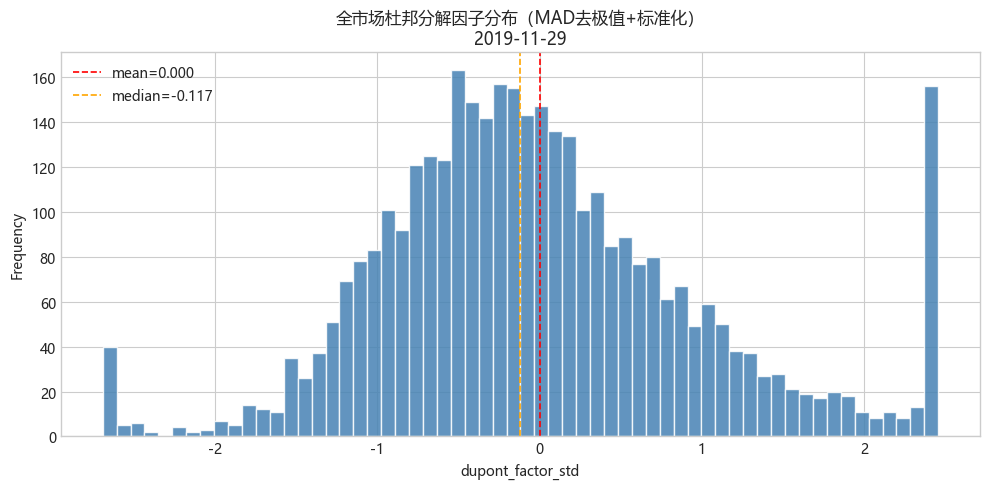

In [17]:
# 依赖前序单元已生成：factor_frames、best_w_l1（或 best_w）、feature_cols
# 1) 选择用于全市场截面的日期（取财务因子共同可用的最后一个月末）
avail_dates = sorted(
    set(factor_frames['ato'].index)
    & set(factor_frames['npm'].index)
    & set(factor_frames['em'].index)
)
if len(avail_dates) == 0:
    raise ValueError('没有可用的因子日期，请先运行前面的数据准备单元。')

factor_date = avail_dates[-1]

# 2) 使用前面训练得到的权重构造杜邦分解因子（全市场）
if 'best_w_l1' in globals():
    w = np.asarray(best_w_l1, dtype=float)
elif 'best_w' in globals():
    w_raw = np.asarray(best_w, dtype=float)
    w = w_raw / np.sum(np.abs(w_raw))
else:
    raise ValueError('未检测到 best_w_l1 或 best_w，请先运行参数训练单元。')

if 'feature_cols' in globals():
    cols = list(feature_cols)
else:
    cols = ['ato', 'npm', 'em']

x_cs = pd.DataFrame({
    'order_book_id': factor_frames['ato'].columns,
    'ato': factor_frames['ato'].loc[factor_date].values,
    'npm': factor_frames['npm'].loc[factor_date].values,
    'em': factor_frames['em'].loc[factor_date].values,
})

for c in ['ato', 'npm', 'em']:
    x_cs[c] = pd.to_numeric(x_cs[c], errors='coerce')

x_cs = x_cs.replace([np.inf, -np.inf], np.nan).dropna(subset=cols).copy()

# 原始杜邦因子值
x_cs['dupont_factor_raw'] = x_cs[cols].to_numpy(dtype=float) @ w

# 3) MAD 去极值
def mad_winsorize(s: pd.Series, k: float = 3.0) -> pd.Series:
    med = s.median()
    mad = np.median(np.abs(s - med))
    if not np.isfinite(mad) or mad == 0:
        return s.copy()
    # 1.4826 * MAD 近似正态分布下标准差
    scale = 1.4826 * mad
    lower = med - k * scale
    upper = med + k * scale
    return s.clip(lower=lower, upper=upper)

x_cs['dupont_factor_mad'] = mad_winsorize(x_cs['dupont_factor_raw'], k=3.0)

# 4) 标准化（z-score）
mean_v = x_cs['dupont_factor_mad'].mean()
std_v = x_cs['dupont_factor_mad'].std(ddof=0)
if std_v > 0:
    x_cs['dupont_factor_std'] = (x_cs['dupont_factor_mad'] - mean_v) / std_v
else:
    x_cs['dupont_factor_std'] = 0.0

print(f'因子截面日期: {pd.Timestamp(factor_date).date()}')
print(f'有效股票数: {len(x_cs):,}')
print('处理后因子统计:')
print(x_cs['dupont_factor_std'].describe(percentiles=[0.01, 0.05, 0.5, 0.95, 0.99]))

# 5) 全市场因子分布图
plt.figure(figsize=(10, 5))
plt.hist(x_cs['dupont_factor_std'], bins=60, color='steelblue', edgecolor='white', alpha=0.85)
plt.axvline(x_cs['dupont_factor_std'].mean(), color='red', linestyle='--', linewidth=1.2, label=f"mean={x_cs['dupont_factor_std'].mean():.3f}")
plt.axvline(x_cs['dupont_factor_std'].median(), color='orange', linestyle='--', linewidth=1.2, label=f"median={x_cs['dupont_factor_std'].median():.3f}")
plt.title(f'全市场杜邦分解因子分布（MAD去极值+标准化）\n{pd.Timestamp(factor_date).date()}')
plt.xlabel('dupont_factor_std')
plt.ylabel('Frequency')
plt.legend()
plt.tight_layout()
plt.show()

# 输出可复用的最终截面结果
dupont_factor_cs = x_cs[['order_book_id', 'dupont_factor_raw', 'dupont_factor_mad', 'dupont_factor_std']].copy()

## 4. 因子有效性检验

c:\Users\Lenovo\AppData\Local\Programs\Python\Python313\Lib\site-packages\rqdatac\client.py:224: UserWarning: rqdatac is already inited. Settings will be changed.
  warnings.warn("rqdatac is already inited. Settings will be changed.", stacklevel=0)


=== 月度 IC / RankIC / ICIR ===
样本月数: 12
IC mean=0.005937, IC std=0.019139, ICIR=0.310205
RankIC mean=0.022230, RankIC std=0.051777, RankICIR=0.429328


,date,ic,rank_ic,n
0,2019-12-31,0.011271,0.020873,3579
1,2020-01-23,0.005721,-0.001840,3584
2,2020-02-28,0.022916,0.127956,3586
3,2020-03-31,0.019220,0.025038,3597
4,2020-04-30,0.035299,0.052818,3650
5,2020-05-29,0.022511,0.062277,3656
6,2020-06-30,-0.007055,0.018792,3656
7,2020-07-31,-0.008537,0.025564,3653
8,2020-08-31,-0.019440,-0.014405,3712
9,2020-09-30,0.023610,0.051469,3714



=== 5分组月度平均收益（G1低因子 -> G5高因子） ===


,date,G1,G2,G3,G4,G5,long_short_5_1
0,2019-12-31,-0.001759,0.011633,0.007671,0.003289,-0.001016,0.000744
1,2020-01-23,-0.008099,0.011966,-0.003000,0.006605,-0.007195,0.000905
2,2020-02-28,-0.054702,-0.048928,-0.044345,-0.023647,-0.013462,0.041240
3,2020-03-31,0.010045,0.022267,0.025336,0.027019,0.021082,0.011037
4,2020-04-30,0.010156,0.016897,0.018206,0.019395,0.026431,0.016275
5,2020-05-29,0.051092,0.065739,0.081523,0.065158,0.075861,0.024770
6,2020-06-30,0.136163,0.121179,0.155306,0.131701,0.129616,-0.006547
7,2020-07-31,0.031253,0.039533,0.036189,0.043828,0.031374,0.000121
8,2020-08-31,-0.066465,-0.067771,-0.061975,-0.068780,-0.075071,-0.008606
9,2020-09-30,-0.010447,0.006283,0.009477,0.002914,0.001617,0.012065


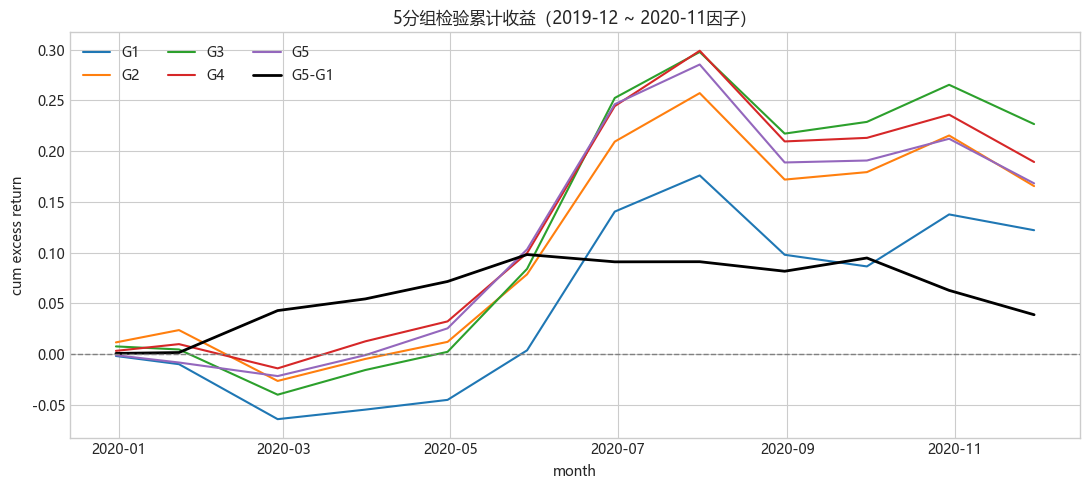


=== 月度截面回归结果（ret_next = a + f*factor） ===


,date,f,t,n
0,2019-12-31,0.000052,0.674166,3579
1,2020-01-23,0.000031,0.342396,3584
2,2020-02-28,0.000118,1.372246,3586
3,2020-03-31,0.000084,1.152584,3597
4,2020-04-30,0.001040,2.133355,3650
5,2020-05-29,0.000705,1.361070,3656
6,2020-06-30,-0.000288,-0.426461,3656
7,2020-07-31,-0.000229,-0.515848,3653
8,2020-08-31,-0.000222,-1.184311,3712
9,2020-09-30,0.000454,1.438859,3714


回归系数 f 的12个月均值: 0.000119
t值 的12个月均值: 0.354876


In [20]:
# ====== 因子有效性检验（全市场，2019-12-31 ~ 2020-12-31） ======
# 要求覆盖：
# (1) 全市场股票，时间 20191231-20201231
# (2) 月度 IC、Rank IC、ICIR
# (3) 5 分组检验
# (4) 月度截面回归（f 与 t），并给出 12 个月均值

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import rqdatac

rqdatac.init()

# ---------- 基础配置 ----------
eval_start = '2019-12-31'
eval_end = '2020-12-31'
label_end = '2021-01-31'  # 为 2020-12 的下一月收益预留
benchmark_id = '000300.XSHG'

# 使用前面训练得到的权重（已是 sum(|w|)=1）
if 'best_w_l1' in globals():
    w_eval = np.asarray(best_w_l1, dtype=float)
elif 'best_w' in globals():
    w_raw_eval = np.asarray(best_w, dtype=float)
    w_eval = w_raw_eval / np.sum(np.abs(w_raw_eval))
else:
    raise ValueError('未检测到 best_w_l1/best_w，请先运行参数训练单元。')

# 全市场股票池
inst_eval = rqdatac.all_instruments(type='CS').copy()
all_ids_eval = inst_eval['order_book_id'].dropna().astype(str).unique().tolist()

# 月末交易日（覆盖评估窗口 + 1 个月标签）
# 为保证6个月动量可计算，回溯至少7个月数据
momentum_lookback_months = 7
momentum_start = (pd.Timestamp(eval_start) - pd.DateOffset(months=momentum_lookback_months)).strftime('%Y-%m-%d')
trade_days_eval = pd.DatetimeIndex(rqdatac.get_trading_dates(start_date=momentum_start, end_date=label_end))
month_ends_eval_all = trade_days_eval.to_series().groupby(trade_days_eval.to_period('M')).max().sort_values()
month_ends_eval_all = pd.DatetimeIndex(month_ends_eval_all.values)

# 用于评估的因子月：2019-12 到 2020-11（共 12 个月），保证都有 next-month 标签
factor_months = month_ends_eval_all[(month_ends_eval_all >= pd.Timestamp(eval_start)) & (month_ends_eval_all < pd.Timestamp(eval_end))]
# ---------- 拉取杜邦三项因子并转宽表（月末） ----------
factor_names_eval = {
    'ato': 'du_asset_turnover_ratio',
    'npm': 'net_profit_to_revenue_ttm',
    'em': 'du_equity_multiplier_ttm',
}


def factor_to_wide_month(df: pd.DataFrame, factor_name: str) -> pd.DataFrame:
    if not isinstance(df, pd.DataFrame) or df.empty:
        raise ValueError(f'get_factor 返回为空：{factor_name}')
    if not isinstance(df.index, pd.MultiIndex):
        raise TypeError(f'get_factor 返回 index 非 MultiIndex：{factor_name}')

    s = df[factor_name] if factor_name in df.columns else df.iloc[:, 0]
    if 'order_book_id' in df.index.names:
        wide = s.unstack('order_book_id')
    else:
        wide = s.unstack(0)

    wide.index = pd.to_datetime(wide.index)
    wide = wide.sort_index().reindex(columns=all_ids_eval)
    # 对齐交易日后前向填充，再截取月末
    wide = wide.reindex(trade_days_eval[trade_days_eval <= pd.Timestamp(eval_end)]).ffill()
    return wide.reindex(factor_months)


factor_eval = {}
for k, fac in factor_names_eval.items():
    raw = rqdatac.get_factor(
        order_book_ids=all_ids_eval,
        factor=fac,
        start_date=eval_start,
        end_date=eval_end,
        expect_df=True,
        market='cn',
    )
    factor_eval[k] = factor_to_wide_month(raw, fac)

# ---------- 构造 next-month 超额收益标签 ----------
price_eval_raw = rqdatac.get_price(
    order_book_ids=all_ids_eval,
    start_date=momentum_start,
    end_date=label_end,
    frequency='1d',
    fields='close',
    adjust_type='pre',
    expect_df=True,
 )
close_eval = price_eval_raw['close'].unstack('order_book_id').sort_index().reindex(columns=all_ids_eval)
close_eval_m = close_eval.reindex(month_ends_eval_all)
stock_fwd_1m_eval = close_eval_m.shift(-1).div(close_eval_m) - 1.0

bench_eval_raw = rqdatac.get_price(
    order_book_ids=[benchmark_id],
    start_date=momentum_start,
    end_date=label_end,
    frequency='1d',
    fields='close',
    expect_df=True,
 )
bench_eval = bench_eval_raw['close'].unstack('order_book_id').sort_index().iloc[:, 0]
bench_eval_m = bench_eval.reindex(month_ends_eval_all)
bench_fwd_1m_eval = bench_eval_m.shift(-1).div(bench_eval_m) - 1.0

excess_fwd_1m_eval = stock_fwd_1m_eval.sub(bench_fwd_1m_eval, axis=0).reindex(factor_months)

# 额外基础变量：市值、动量、换手、波动、行业
# 使用 get_instrument_industry (citics_2019 一级行业) 来获取行业，避免过细或缺失问题
industry_info = rqdatac.get_instrument_industry(
    order_book_ids=all_ids_eval,
    source='citics_2019',
    level=1,
    date=eval_start,
    market='cn',
)
# 有的版本返回 DataFrame，有的返回 Series (industry names)，统一处理。
if isinstance(industry_info, pd.DataFrame):
    industry_map = industry_info.reset_index().set_index('order_book_id')['first_industry_name'].fillna('Unknown')
else:
    # 若直接返回 type 为 Series 或 dict-like
    industry_map = pd.Series(industry_info).rename_axis('order_book_id').fillna('Unknown')

mktcap_raw = rqdatac.get_factor(
    order_book_ids=all_ids_eval,
    factor='market_cap',
    start_date=eval_start,
    end_date=eval_end,
    expect_df=True,
    market='cn',
)
mktcap_month = factor_to_wide_month(mktcap_raw, 'market_cap')

turn_raw = rqdatac.get_turnover_rate(
    order_book_ids=all_ids_eval,
    start_date=eval_start,
    end_date=eval_end,
    fields=['today', 'week', 'month', 'year'],
    expect_df=True,
    market='cn',
)
# get_turnover_rate 返回的 DataFrame 结构通常是 index=(order_book_id, date)
# 用今天换手率作为截面特征
turn_month = factor_to_wide_month(turn_raw, 'month')

# 动量：6个月收益率
mom_month = close_eval_m.pct_change(6).reindex(factor_months)

# 波动：60个交易日收益率标准差的月末
daily_ret_eval = close_eval.pct_change().reindex(trade_days_eval)
vol_month = daily_ret_eval.rolling(window=60, min_periods=20).std().reindex(month_ends_eval_all).reindex(factor_months)

# ---------- 工具函数：MAD 去极值 + 标准化 ----------
def mad_clip_standardize(s: pd.Series, k: float = 5.0) -> pd.Series:
    s = pd.to_numeric(s, errors='coerce')
    med = s.median()
    mad = np.median(np.abs(s - med))
    if pd.notna(mad) and mad > 0:
        # scale = 1.4826 * mad
        scale = mad
        s = s.clip(lower=med - k * scale, upper=med + k * scale)
    std = s.std(ddof=0)
    if pd.notna(std) and std > 0:
        s = (s - s.mean()) / std
    else:
        s = s * 0.0
    return s


def neutralize_factor_cross_section(cs: pd.DataFrame, factor_col: str = 'factor_raw') -> pd.Series:
    """针对一组截面样本按市值、动量、换手、波动、行业进行中性化，返回残差。"""
    work = cs[[factor_col, 'mktcap', 'mom', 'turn', 'vol', 'industry']].copy()
    work = work.replace([np.inf, -np.inf], np.nan)
    work['log_mktcap'] = np.log1p(work['mktcap'])

    work = work.drop(columns=['mktcap'])
    work = work.dropna(subset=[factor_col, 'log_mktcap', 'mom', 'turn', 'vol'])

    industry_dummies = pd.get_dummies(work['industry'], prefix='ind', dummy_na=False, drop_first=True)
    X = pd.concat([work[['log_mktcap', 'mom', 'turn', 'vol']], industry_dummies], axis=1)
    X = np.asarray(pd.concat([pd.Series(1.0, index=X.index, name='const'), X], axis=1).astype(float))

    y = pd.to_numeric(work[factor_col], errors='coerce').astype(float)
    valid_mask = np.isfinite(y.to_numpy(dtype=float)) & np.isfinite(X).all(axis=1)
    if not np.any(valid_mask):
        return pd.Series(np.nan, index=cs.index, dtype=float)

    y_clean = y.to_numpy(dtype=float)[valid_mask]
    X_clean = X[valid_mask]

    if len(y_clean) < 20:
        out = pd.Series(np.nan, index=cs.index, dtype=float)
        if np.isfinite(y_clean).any():
            out.loc[work.index[valid_mask]] = y_clean - np.nanmean(y_clean)
        return out

    beta, *_ = np.linalg.lstsq(X_clean, y_clean, rcond=None)
    residual = y_clean - X_clean @ beta

    res = pd.Series(np.nan, index=cs.index, dtype=float)
    res.loc[work.index[valid_mask]] = residual
    return res


 # ---------- 逐月评估：IC / RankIC / 分组 / 截面回归 ----------
ic_rows = []
group_rows = []
reg_rows = []

for dt in factor_months:
    cs = pd.DataFrame({
        'order_book_id': all_ids_eval,
        'ato': factor_eval['ato'].loc[dt].values,
        'npm': factor_eval['npm'].loc[dt].values,
        'em': factor_eval['em'].loc[dt].values,
        'ret_next':stock_fwd_1m_eval.loc[dt].values,
    })

    for c in ['ato', 'npm', 'em', 'ret_next']:
        cs[c] = pd.to_numeric(cs[c], errors='coerce')

    cs = cs.replace([np.inf, -np.inf], np.nan).dropna(subset=['ato', 'npm', 'em', 'ret_next']).copy()
    if len(cs) < 100:
        continue

    # 按前面训练得到的权重构造原始杜邦分解因子
    mktcap_dt = mktcap_month.loc[dt].reindex(cs['order_book_id']).values
    mom_dt = mom_month.loc[dt].reindex(cs['order_book_id']).values
    turn_dt = turn_month.loc[dt].reindex(cs['order_book_id']).values
    vol_dt = vol_month.loc[dt].reindex(cs['order_book_id']).values

    cs['mktcap'] = mktcap_dt
    cs['mom'] = mom_dt
    cs['turn'] = turn_dt
    cs['vol'] = vol_dt
    cs['industry'] = cs['order_book_id'].map(industry_map).fillna('Unknown')

    cs['factor_raw'] = cs[['ato', 'npm', 'em']].to_numpy(dtype=float) @ w_eval
    cs['factor_neutral'] = neutralize_factor_cross_section(cs, factor_col='factor_raw')
    cs['factor'] = mad_clip_standardize(cs['factor_neutral'], k=3.0)

    cs_valid = cs.replace([np.inf, -np.inf], np.nan).dropna(subset=['factor', 'ret_next']).copy()
    if len(cs_valid) < 30:
        continue

    # (2) 月度 IC / Rank IC
    ic = cs_valid['factor'].corr(cs_valid['ret_next'], method='pearson')
    rank_ic = cs_valid['factor'].corr(cs_valid['ret_next'], method='spearman')
    ic_rows.append({'date': pd.Timestamp(dt), 'ic': ic, 'rank_ic': rank_ic, 'n': int(len(cs_valid))})

    # (3) 5分组检验（按因子由低到高分组）
    cs_valid = cs_valid.sort_values('factor').copy()
    cs_valid['group'] = pd.qcut(cs_valid['factor'], q=5, labels=[1, 2, 3, 4, 5], duplicates='drop')
    gret = cs_valid.groupby('group')['ret_next'].mean()
    row = {'date': pd.Timestamp(dt)}
    for g in [1, 2, 3, 4, 5]:
        row[f'G{g}'] = float(gret.get(g, np.nan))
    row['long_short_5_1'] = row['G5'] - row['G1']
    group_rows.append(row)

    # (4) 截面回归：ret_next = a + f * factor + e
    x = cs_valid['factor_neutral'].to_numpy(dtype=float)
    y = cs_valid['ret_next'].to_numpy(dtype=float)
    finite_mask = np.isfinite(x) & np.isfinite(y)
    x = x[finite_mask]
    y = y[finite_mask]
    if len(x) < 30:
        continue
    x_mean = x.mean()
    y_mean = y.mean()
    sxx = np.sum((x - x_mean) ** 2)

    if sxx > 0 and len(x) > 2:
        f_hat = np.sum((x - x_mean) * (y - y_mean)) / sxx
        a_hat = y_mean - f_hat * x_mean
        resid = y - (a_hat + f_hat * x)
        sigma2 = np.sum(resid ** 2) / (len(x) - 2)
        se_f = np.sqrt(sigma2 / sxx) if sigma2 >= 0 else np.nan
        t_f = f_hat / se_f if (pd.notna(se_f) and se_f > 0) else np.nan
    else:
        f_hat, t_f = np.nan, np.nan

    reg_rows.append({'date': pd.Timestamp(dt), 'f': f_hat, 't': t_f, 'n': int(len(x))})

if len(reg_rows) == 0:
    raise ValueError('月度截面回归没有生成任何有效月份，请先检查因子是否全为 NaN 或样本阈值是否过高。')

ic_df = pd.DataFrame(ic_rows).sort_values('date').reset_index(drop=True)
group_df = pd.DataFrame(group_rows).sort_values('date').reset_index(drop=True)
reg_df = pd.DataFrame(reg_rows).sort_values('date').reset_index(drop=True)

# 统计指标
ic_mean = ic_df['ic'].mean()
ic_std = ic_df['ic'].std(ddof=1)
icir = ic_mean / ic_std if (pd.notna(ic_std) and ic_std > 0) else np.nan
rank_ic_mean = ic_df['rank_ic'].mean()
rank_ic_std = ic_df['rank_ic'].std(ddof=1)
rank_icir = rank_ic_mean / rank_ic_std if (pd.notna(rank_ic_std) and rank_ic_std > 0) else np.nan

print('=== 月度 IC / RankIC / ICIR ===')
print(f"样本月数: {len(ic_df)}")
print(f"IC mean={ic_mean:.6f}, IC std={ic_std:.6f}, ICIR={icir:.6f}")
print(f"RankIC mean={rank_ic_mean:.6f}, RankIC std={rank_ic_std:.6f}, RankICIR={rank_icir:.6f}")
display(ic_df)

print('\n=== 5分组月度平均收益（G1低因子 -> G5高因子） ===')
display(group_df)

# 5分组累计表现图
cum_group = (1.0 + group_df[['G1', 'G2', 'G3', 'G4', 'G5', 'long_short_5_1']]).cumprod() - 1.0
plt.figure(figsize=(11, 5))
for c in ['G1', 'G2', 'G3', 'G4', 'G5']:
    plt.plot(group_df['date'], cum_group[c], label=c)
plt.plot(group_df['date'], cum_group['long_short_5_1'], label='G5-G1', linewidth=2.0, color='black')
plt.axhline(0, linestyle='--', color='gray', linewidth=1)
plt.title('5分组检验累计收益（2019-12 ~ 2020-11因子）')
plt.xlabel('month')
plt.ylabel('cum excess return')
plt.legend(ncol=3)
plt.tight_layout()
plt.show()

print('\n=== 月度截面回归结果（ret_next = a + f*factor） ===')
display(reg_df)

# 按要求给出12个月均值
reg_12 = reg_df.tail(12)
print(f"回归系数 f 的12个月均值: {reg_12['f'].mean():.6f}")
print(f"t值 的12个月均值: {reg_12['t'].mean():.6f}")

# 结果变量保留，便于后续复用
factor_eval_ic_df = ic_df.copy()
factor_eval_group_df = group_df.copy()
factor_eval_reg_df = reg_df.copy()